# **BÀI TẬP MÔN MACHINE LEARNING: PHÂN TÍCH VÀ TIỀN XỬ LÝ BỘ DỮ LIỆU OULAD**
**File:** 01_Data_Structure.ipynb  
**Họ và tên:** Hà Hoàng Kim Chi  
**Mã sinh viên:** 24021393  
**Lớp:** K69I-CS5

---

## MỤC LỤC
1. [Giới thiệu bộ dữ liệu](#1.-Giới-thiệu-bộ-dữ-liệu)
2. [Khai báo các thư viện cần thiết](#2.-Khai-báo-các-thư-viện-cần-thiết)
3. [Đọc và tải dữ liệu](#3.-Đọc-và-tải-dữ-liệu)
4. [Tổng quan cấu trúc các bảng và sơ đồ liên kết](#4.-Tổng-quan-cấu-trúc-các-bảng-và-sơ-đồ-liên-kết)
5. [Bảng từ điển dữ liệu (Data Dictionary)](#5.-Bảng-từ-điển-dữ-liệu-(Data-Dictionary))
6. [Khái quát bài toán Machine Learning](#6.-Khái-quát-bài-toán-Machine-Learning)
7. [Mốc thời gian dự đoán (Prediction Time Window Cutoff)](#7.-Mốc-thời-gian-dự-đoán-(Prediction-Time-Window-Cutoff))

# 1. Giới thiệu bộ dữ liệu

Bộ dữ liệu **OULAD (Open University Learning Analytics Dataset)** chứa thông tin học tập trực tuyến của các khóa học tại Đại học Mở (Open University - UK).

Bộ dữ liệu bao gồm **7 bảng CSV** ghi lại thông tin chi tiết về nhân khẩu học của sinh viên, quá trình đăng ký môn học, kết quả bài đánh giá và lịch sử tương tác của sinh viên trên hệ thống môi trường học tập ảo VLE (Virtual Learning Environment).

# 2. Khai báo các thư viện cần thiết

In [2]:
import os
import zipfile
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import plotly.express as px
from sklearn.preprocessing import LabelEncoder

# 3. Đọc và tải dữ liệu

In [3]:
assessments = pd.read_csv('data/assessments.csv')
courses = pd.read_csv('data/courses.csv')
student_assessment = pd.read_csv('data/studentAssessment.csv')
student_info = pd.read_csv('data/studentInfo.csv')
student_registration = pd.read_csv('data/studentRegistration.csv')
student_vle = pd.read_csv('data/studentVle.csv')
vle = pd.read_csv('data/vle.csv')

# 4. Tổng quan cấu trúc các bảng và sơ đồ liên kết

In [4]:
dfs = {
    "courses": courses,
    "assessments": assessments,
    "vle": vle,
    "studentInfo": student_info,
    "studentRegistration": student_registration,
    "studentAssessment": student_assessment,
    "studentVle": student_vle
}

for name, df in dfs.items():
    print(f"=== BẢNG: {name} ===")
    print(f"Kích thước: {df.shape}")
    display(df.head(3))
    df.info()
    print("\nSố lượng giá trị bị thiếu (NaN):")
    print(df.isna().sum()[df.isna().sum() > 0]) # Chỉ in các cột có NaN
    print("-" * 60)

=== BẢNG: courses ===
Kích thước: (22, 3)


,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268


<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   code_module                 22 non-null     str  
 1   code_presentation           22 non-null     str  
 2   module_presentation_length  22 non-null     int64
dtypes: int64(1), str(2)
memory usage: 660.0 bytes

Số lượng giá trị bị thiếu (NaN):
Series([], dtype: int64)
------------------------------------------------------------
=== BẢNG: assessments ===
Kích thước: (206, 6)


,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0


<class 'pandas.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   code_module        206 non-null    str    
 1   code_presentation  206 non-null    str    
 2   id_assessment      206 non-null    int64  
 3   assessment_type    206 non-null    str    
 4   date               195 non-null    float64
 5   weight             206 non-null    float64
dtypes: float64(2), int64(1), str(3)
memory usage: 9.8 KB

Số lượng giá trị bị thiếu (NaN):
date    11
dtype: int64
------------------------------------------------------------
=== BẢNG: vle ===
Kích thước: (6364, 6)


...

<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   code_module          32593 non-null  str    
 1   code_presentation    32593 non-null  str    
 2   id_student           32593 non-null  int64  
 3   date_registration    32548 non-null  float64
 4   date_unregistration  10072 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 1.2 MB

Số lượng giá trị bị thiếu (NaN):
date_registration         45
date_unregistration    22521
dtype: int64
------------------------------------------------------------
=== BẢNG: studentAssessment ===
Kích thước: (173912, 5)


,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0


<class 'pandas.DataFrame'>
RangeIndex: 173912 entries, 0 to 173911
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id_assessment   173912 non-null  int64  
 1   id_student      173912 non-null  int64  
 2   date_submitted  173912 non-null  int64  
 3   is_banked       173912 non-null  int64  
 4   score           173739 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 6.6 MB

Số lượng giá trị bị thiếu (NaN):
score    173
dtype: int64
------------------------------------------------------------
=== BẢNG: studentVle ===
Kích thước: (10655280, 6)


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1


<class 'pandas.DataFrame'>
RangeIndex: 10655280 entries, 0 to 10655279
Data columns (total 6 columns):
 #   Column             Dtype
---  ------             -----
 0   code_module        str  
 1   code_presentation  str  
 2   id_student         int64
 3   id_site            int64
 4   date               int64
 5   sum_click          int64
dtypes: int64(4), str(2)
memory usage: 487.8 MB

Số lượng giá trị bị thiếu (NaN):
Series([], dtype: int64)
------------------------------------------------------------


### Sơ đồ mối quan hệ giữa các bảng (Entity Relationship Structure)

Hệ thống bộ dữ liệu OULAD bao gồm các bảng được liên kết chặt chẽ thông qua hệ thống khóa chính (Primary Key - PK) và khóa ngoại (Foreign Key - FK) như sau:

1. **`courses` $\leftrightarrow$ `assessments`, `studentInfo`, `studentRegistration`, `vle`**:
   * Bảng `courses` quản lý danh mục môn học với khóa chính hợp phần là `(code_module, code_presentation)`.
   * Bộ khóa này đóng vai trò khóa ngoại trong 4 bảng trên để xác định môn học và học kỳ tương ứng.

2. **`studentInfo` $\leftrightarrow$ `studentRegistration`**:
   * Liên kết với nhau qua bộ khóa ngoại `(code_module, code_presentation, id_student)`. Bộ khóa này giúp định danh duy nhất lượt đăng ký môn học của từng sinh viên trong một học kỳ cụ thể.

3. **`assessments` $\leftrightarrow$ `studentAssessment`**:
   * Bảng `assessments` sử dụng `id_assessment` làm khóa chính (PK). 
   * Trường `id_assessment` xuất hiện trong `studentAssessment` dưới dạng khóa ngoại (FK) để liên kết kết quả làm bài với bài kiểm tra tương ứng.

4. **`studentAssessment` $\leftrightarrow$ `studentInfo`**:
   * Bảng `studentAssessment` liên kết ngược lại với bảng `studentInfo` qua khóa ngoại `id_student` để xác định sinh viên nộp bài.

5. **`vle` $\leftrightarrow$ `studentVle`**:
   * Bảng `vle` quản lý tài nguyên học tập với khóa chính `id_site` (PK).
   * Trường `id_site` làm khóa ngoại (FK) trong bảng `studentVle` để ghi nhận tài nguyên VLE mà sinh viên đã truy cập.

6. **`studentVle` $\leftrightarrow$ `studentInfo` / `courses`**:
   * Bảng `studentVle` sử dụng bộ khóa hợp phần `(code_module, code_presentation, id_student)` làm khóa ngoại để định danh chính xác nhật ký tương tác (click) của sinh viên trong môn học và học kỳ đó.

# 5. Bảng từ điển dữ liệu (Data Dictionary)

### 5.1. Bảng `courses.csv` (Môn học và kỳ học)
| Cột | Kiểu dữ liệu | Mô tả |
| :--- | :--- | :--- |
| `code_module` | String | Mã danh mục môn học |
| `code_presentation` | String | Mã học kỳ (ví dụ: 2013B - kỳ tháng 2, 2013J - kỳ tháng 10) |
| `module_presentation_length` | Integer | Độ dài học kỳ (tính theo số ngày) |

---

### 5.2. Bảng `assessments.csv` (Thông tin bài đánh giá)
| Cột | Kiểu dữ liệu | Mô tả |
| :--- | :--- | :--- |
| `code_module` | String | Mã môn học |
| `code_presentation` | String | Mã học kỳ |
| `id_assessment` | Integer | ID duy nhất của bài đánh giá |
| `assessment_type` | String | Loại bài đánh giá (TMA - Tutor Marked, CMA - Computer Marked, Exam) |
| `date` | Float | Ngày hạn nộp bài đánh giá (tính từ ngày bắt đầu kỳ học) |
| `weight` | Float | Trọng số bài đánh giá (%) đóng góp vào điểm cuối kỳ |

---

### 5.3. Bảng `vle.csv` (Tài nguyên hệ thống VLE)
| Cột | Kiểu dữ liệu | Mô tả |
| :--- | :--- | :--- |
| `id_site` | Integer | ID duy nhất của tài nguyên/trang VLE |
| `code_module` | String | Mã môn học |
| `code_presentation` | String | Mã học kỳ |
| `activity_type` | String | Loại tài nguyên (forumng, quiz, resource, url, page, v.v.) |
| `week_from` | Float | Tuần dự kiến bắt đầu sử dụng tài nguyên |
| `week_to` | Float | Tuần dự kiến kết thúc sử dụng tài nguyên |

---

### 5.4. Bảng `studentInfo.csv` (Thông tin nhân khẩu học sinh viên)
| Cột | Kiểu dữ liệu | Mô tả |
| :--- | :--- | :--- |
| `code_module` | String | Mã môn học đăng ký |
| `code_presentation` | String | Mã học kỳ |
| `id_student` | Integer | ID duy nhất đại diện cho sinh viên |
| `gender` | String | Giới tính (M / F) |
| `region` | String | Vùng địa lý sinh sống của sinh viên |
| `highest_education` | String | Trình độ học vấn cao nhất trước khi nhập học |
| `imd_band` | String | Chỉ số thiếu hụt vùng (Index of Multiple Deprivation) |
| `age_band` | String | Nhóm tuổi (<35, 35-55, >=55) |
| `num_of_prev_attempts` | Integer | Số lần đã học lại/thi lại môn này trước đó |
| `studied_credits` | Integer | Tổng số tín chỉ sinh viên đang học đồng thời |
| `disability` | String | Tình trạng khuyết tật (Y / N) |
| `final_result` | String | Kết quả cuối khóa (Pass, Fail, Withdrawn, Distinction) |

---

### 5.5. Bảng `studentRegistration.csv` (Thông tin đăng ký/rút môn)
| Cột | Kiểu dữ liệu | Mô tả |
| :--- | :--- | :--- |
| `code_module` | String | Mã môn học |
| `code_presentation` | String | Mã học kỳ |
| `id_student` | Integer | ID sinh viên |
| `date_registration` | Float | Ngày đăng ký môn học (tính so với ngày bắt đầu kỳ học) |
| `date_unregistration` | Float | Ngày hủy đăng ký môn học (NaN nếu không hủy) |

---

### 5.6. Bảng `studentAssessment.csv` (Kết quả làm bài của sinh viên)
| Cột | Kiểu dữ liệu | Mô tả |
| :--- | :--- | :--- |
| `id_assessment` | Integer | ID của bài đánh giá |
| `id_student` | Integer | ID sinh viên |
| `date_submitted` | Integer | Ngày sinh viên thực tế nộp bài |
| `is_banked` | Integer | Trạng thái bảo lưu điểm từ kỳ trước (1: Có, 0: Không) |
| `score` | Float | Điểm số đạt được (thang điểm 0 - 100) |

---

### 5.7. Bảng `studentVle.csv` (Lịch sử tương tác VLE)
| Cột | Kiểu dữ liệu | Mô tả |
| :--- | :--- | :--- |
| `code_module` | String | Mã môn học |
| `code_presentation` | String | Mã học kỳ |
| `id_student` | Integer | ID sinh viên |
| `id_site` | Integer | ID của tài nguyên VLE đã tương tác |
| `date` | Integer | Ngày tương tác (tính so với ngày bắt đầu kỳ học) |
| `sum_click` | Integer | Tổng số lần nhấp chuột/truy cập trong ngày đó |

# 6. Khái quát bài toán Machine Learning (Problem Formulation)

Sau khi đọc và khám phá cấu trúc dữ liệu thô OULAD, ta xác định định hướng bài toán Học máy (Machine Learning) như sau:

* **Bài toán tổng quát:** Dự đoán kết quả học tập cuối khóa của sinh viên dựa trên thông tin nhân khẩu học, điểm số các bài đánh giá ban đầu và lịch sử tương tác trên hệ thống VLE.
* **Loại bài toán ML:** **Classification (Phân loại)**.
* **Biến mục tiêu (Target Variable):** `final_result` thuộc bảng `studentInfo.csv`.
  * Biến mục tiêu có 4 giá trị định danh bao gồm:
    1. **`Distinction`**: Sinh viên đạt kết quả Xuất sắc.
    2. **`Pass`**: Sinh viên Đạt (Đạt điểm chuẩn tối thiểu).
    3. **`Fail`**: Sinh viên Trượt (Không đủ điều kiện qua môn).
    4. **`Withdrawn`**: Sinh viên Hủy/Rút môn học trước khi kết thúc khóa học.

* **Bài toán mở rộng/Biến đổi nhãn (Problem Formulations):**
  * **Phân loại 4 lớp (Multi-class Classification):** Giữ nguyên 4 giá trị (`Distinction`, `Pass`, `Fail`, `Withdrawn`).
  * **Phân loại nhị phân (Binary Classification - Dự đoán nguy cơ bỏ học / Trượt):**
    * Nhóm 0 (Unsuccessful / At-Risk): `Fail` + `Withdrawn`
    * Nhóm 1 (Successful): `Pass` + `Distinction`

=== PHÂN BỐ BIẾN MỤC TIÊU (final_result) ===


,Số lượng sinh viên,Tỷ lệ (%)
final_result,,
Pass,12361,37.93
Withdrawn,10156,31.16
Fail,7052,21.64
Distinction,3024,9.28


C:\Users\Admin\AppData\Local\Temp\ipykernel_5488\834482554.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_target_summary.index, y=df_target_summary['Số lượng sinh viên'], palette='Set2')


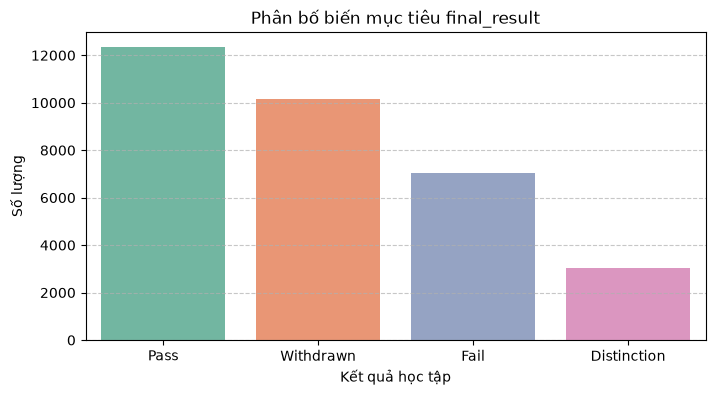

In [5]:
# Kiểm tra phân bố và tỷ lệ phần trăm của cột mục tiêu (final_result)
target_counts = student_info['final_result'].value_counts()
target_percentage = student_info['final_result'].value_counts(normalize=True) * 100

df_target_summary = pd.DataFrame({
    'Số lượng sinh viên': target_counts,
    'Tỷ lệ (%)': target_percentage.round(2)
})

print("=== PHÂN BỐ BIẾN MỤC TIÊU (final_result) ===")
display(df_target_summary)

# Trực quan hóa biến mục tiêu
plt.figure(figsize=(8, 4))
sns.barplot(x=df_target_summary.index, y=df_target_summary['Số lượng sinh viên'], palette='Set2')
plt.title('Phân bố biến mục tiêu final_result')
plt.xlabel('Kết quả học tập')
plt.ylabel('Số lượng')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 7. Mốc thời gian dự đoán (Prediction Time Window Cutoff)

### 7.1. Ý nghĩa và tầm quan trọng của Cắt mốc thời gian (Cutoff Day)
Trong thực tế áp dụng Học máy cho giáo dục (Learning Analytics), hệ thống cảnh báo sớm cần phải đưa ra dự đoán **ngay trong quá trình khóa học đang diễn ra** để giảng viên kịp thời hỗ trợ sinh viên có nguy cơ trượt hoặc bỏ học.

* Ngày $0$ ($Day = 0$) đại diện cho ngày chính thức bắt đầu kỳ học. Các giá trị âm ($Day < 0$) ghi nhận hoạt động đăng ký hoặc tương tác VLE sớm trước khai giảng.
* Nếu dùng toàn bộ dữ liệu đến hết kỳ học để dự đoán, mô hình sẽ bị hiện tượng **Rò rỉ dữ liệu (Data Leakage)**, do điểm số các bài kiểm tra cuối kỳ hay các lượt click ở tuần cuối môn học đã thể hiện rõ kết quả Pass/Fail.
* Do đó, ta cần xác định mốc thời gian chốt cắt dữ liệu **Cutoff Day ($T$)** (ví dụ: $T = 30$, $T = 60$, hay $T = 90$ ngày kể từ khi bắt đầu khóa học).

### 7.2. Nguyên tắc lọc dữ liệu theo Cutoff Day ($T$)
1. **Dữ liệu nhân khẩu học (`studentInfo`):** Giữ nguyên vì đây là thông tin cố định từ đầu khóa.
2. **Lịch sử tương tác VLE (`studentVle`):** Chỉ lấy các dòng thỏa mãn `date <= T`.
3. **Kết quả bài đánh giá (`studentAssessment` & `assessments`):** Chỉ giữ lại các bài kiểm tra có hạn nộp hoặc ngày sinh viên thực tế nộp bài `date_submitted <= T`.

In [6]:
# Định nghĩa mốc Cutoff Day thử nghiệm (ví dụ: Cutoff tại ngày thứ 60 của khóa học)
CUTOFF_DAY = 60

print(f"=== TIẾN HÀNH LỌC DỮ LIỆU VỚI CUTOFF DAY = {CUTOFF_DAY} ===")

# 1. Lọc dữ liệu tương tác VLE
student_vle_cutoff = student_vle[student_vle['date'] <= CUTOFF_DAY].copy()
print(f"- Số bản ghi studentVle trước khi lọc: {len(student_vle):,}")
print(f"- Số bản ghi studentVle sau Cutoff Day {CUTOFF_DAY}: {len(student_vle_cutoff):,}")

# 2. Lọc dữ liệu nộp bài đánh giá
student_assessment_cutoff = student_assessment[student_assessment['date_submitted'] <= CUTOFF_DAY].copy()
print(f"- Số bản ghi studentAssessment trước khi lọc: {len(student_assessment):,}")
print(f"- Số bản ghi studentAssessment sau Cutoff Day {CUTOFF_DAY}: {len(student_assessment_cutoff):,}")

# 3. Trích xuất đặc trưng đơn giản từ studentVle trước Cutoff (Tổng số lượt click theo từng sinh viên)
vle_features_cutoff = student_vle_cutoff.groupby(
    ['code_module', 'code_presentation', 'id_student']
)['sum_click'].agg(
    total_clicks_before_cutoff='sum',
    active_days_before_cutoff='nunique'
).reset_index()

print("\nVí dụ bảng đặc trưng trích xuất từ studentVle trước mốc Cutoff:")
display(vle_features_cutoff.head(5))

=== TIẾN HÀNH LỌC DỮ LIỆU VỚI CUTOFF DAY = 60 ===
- Số bản ghi studentVle trước khi lọc: 10,655,280
- Số bản ghi studentVle sau Cutoff Day 60: 4,499,256
- Số bản ghi studentAssessment trước khi lọc: 173,912
- Số bản ghi studentAssessment sau Cutoff Day 60: 54,744

Ví dụ bảng đặc trưng trích xuất từ studentVle trước mốc Cutoff:


,code_module,code_presentation,id_student,total_clicks_before_cutoff,active_days_before_cutoff
0,AAA,2013J,11391,529,19
1,AAA,2013J,28400,669,16
2,AAA,2013J,30268,281,13
3,AAA,2013J,31604,816,16
4,AAA,2013J,32885,605,18
